# Adult Income — Data Preprocessing & Preparation

## Problem statement
A company wants to predict whether an individual's annual income exceeds $50K based on demographic and employment-related information.

## Dataset
Adult Income Dataset: `adult.csv`

## Learning goals
- Understand a tabular classification dataset
- Identify missing values represented as `?`
- Clean categorical variables
- Encode categorical features
- Scale numerical variables where appropriate
- Inspect class imbalance
- Prepare train/test dataset splits for classification
- Bonus: analyze data for class imbalances
- Bonus: compare model performance before and after preprocessing

## 1. Setup
Import the libraries needed for data inspection, preprocessing, visualization, and optional modeling.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay
)

## 2. Load and Inspect the Data
Load the dataset and inspect its basic structure.

Note: depending on the source, the Adult dataset may not include column names. If needed, use the provided list below.

In [4]:
df = pd.read_excel("adult.xlsx")


In [6]:
df.head(10)


,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K
5,37,Private,284582,Masters,14,Married-civ-spouse,Exec-managerial,Wife,White,Female,0,0,40,United-States,<=50K
6,49,Private,160187,9th,5,Married-spouse-absent,Other-service,Not-in-family,Black,Female,0,0,16,Jamaica,<=50K
7,52,Self-emp-not-inc,209642,HS-grad,9,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,45,United-States,>50K
8,31,Private,45781,Masters,14,Never-married,Prof-specialty,Not-in-family,White,Female,14084,0,50,United-States,>50K
9,42,Private,159449,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,5178,0,40,United-States,>50K


## 3. Data Understanding
Identify the target variable, numerical features, and categorical features.

Questions to answer:
- What does each column represent?
- Which column is the target?
- Which features are numerical?
- Which features are categorical?
- Is the target balanced?

In [9]:
df.shape

(32561, 15)

In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   age             32561 non-null  int64
 1   workclass       32561 non-null  str  
 2   fnlwgt          32561 non-null  int64
 3   education       32561 non-null  str  
 4   education-num   32561 non-null  int64
 5   marital-status  32561 non-null  str  
 6   occupation      32561 non-null  str  
 7   relationship    32561 non-null  str  
 8   race            32561 non-null  str  
 9   sex             32561 non-null  str  
 10  capital-gain    32561 non-null  int64
 11  capital-loss    32561 non-null  int64
 12  hours-per-week  32561 non-null  int64
 13  native-country  32561 non-null  str  
 14  income          32561 non-null  str  
dtypes: int64(6), str(9)
memory usage: 3.7 MB


In [10]:
df.describe()

,age,fnlwgt,education-num,capital-gain,capital-loss,hours-per-week
count,32561.000000,3.256100e+04,32561.000000,32561.000000,32561.000000,32561.000000
mean,38.581647,1.897784e+05,10.080679,1077.648844,87.303830,40.437456
std,13.640433,1.055500e+05,2.572720,7385.292085,402.960219,12.347429
min,17.000000,1.228500e+04,1.000000,0.000000,0.000000,1.000000
25%,28.000000,1.178270e+05,9.000000,0.000000,0.000000,40.000000
50%,37.000000,1.783560e+05,10.000000,0.000000,0.000000,40.000000
75%,48.000000,2.370510e+05,12.000000,0.000000,0.000000,45.000000
max,90.000000,1.484705e+06,16.000000,99999.000000,4356.000000,99.000000


In [11]:
df["income"].value_counts()

income
<=50K    24720
>50K      7841
Name: count, dtype: int64

In [12]:
df["income"].value_counts(normalize=True)

income
<=50K    0.75919
>50K     0.24081
Name: proportion, dtype: float64

- target is: income  
values: <=50K, >50K  
not balanced


## 4. Data Cleaning
The Adult dataset often contains missing values represented as `?`.

Tasks:
- Convert `?` to missing values if not already done
- Check missing values by column
- Decide whether to drop or impute missing values
- Check duplicates
- Clean target labels if needed (`<=50K`, `>50K`, sometimes with trailing dots)

In [14]:
(df.astype(str)
   .apply(lambda col: col.str.strip())
   .eq("?")
   .sum())

age                  0
workclass         1836
fnlwgt               0
education            0
education-num        0
marital-status       0
occupation        1843
relationship         0
race                 0
sex                  0
capital-gain         0
capital-loss         0
hours-per-week       0
native-country     583
income               0
dtype: int64

In [16]:
# replace ? with null vlaues
df = df.replace(r"^\s*\?\s*$", np.nan, regex=True)

In [22]:
missing = df.isnull().sum()
missing[missing > 0].sort_values(ascending=False)

occupation        1843
workclass         1836
native-country     583
dtype: int64

In [23]:
# check how many rows have any missing value
df.isnull().any(axis=1).sum()

np.int64(2399)

In [25]:
# check missing values overlap
df[
    df["occupation"].isnull() &
    df["workclass"].isnull()
].shape[0]

1836

In [26]:
# check missing values overlap
df[
    df["occupation"].isnull() &
    df["workclass"].isnull() &
    df["native-country"].isnull()
].shape[0]

27

In [27]:
df[df["occupation"].isnull()]["workclass"].value_counts(dropna=False)

workclass
NaN              1836
 Never-worked       7
Name: count, dtype: int64

workclass and occupation missingness may carry information. For example unemplyed.
native-country missingness is relatively small (~1.8%).

Missing values were found in three categorical columns: workclass, occupation, and native-country.

For occupation, 1,843 values were missing. Further analysis showed that 1,836 of these rows also had missing workclass. The remaining 7 rows had workclass = "Never-worked", so missing occupation is logically expected. These 7 occupation values may be replaced with "Not Applicable". But as they are only 7, they will be treated as the other and replaced with "Unknown"

The remaining missing values in workclass and occupation were replaced with "Unknown", because the missingness may contain useful information and should not be silently converted to the most frequent category. (for example Students, not employed..)

For native-country, missing values were relatively few and do not seem to have the same business meaning. Therefore, they were replaced with the most frequent value (mode).

In [28]:
df["workclass"] = df["workclass"].fillna("Unknown")
df["occupation"] = df["occupation"].fillna("Unknown")

df["native-country"] = df["native-country"].fillna(
    df["native-country"].mode()[0]
)

df.isnull().sum()

age               0
workclass         0
fnlwgt            0
education         0
education-num     0
marital-status    0
occupation        0
relationship      0
race              0
sex               0
capital-gain      0
capital-loss      0
hours-per-week    0
native-country    0
income            0
dtype: int64

In [39]:
# check duplicates
duplicate_count = df.duplicated().sum()
duplicates = df[df.duplicated(keep=False)]

print(f"duplicates: {duplicate_count}")

duplicates.sort_values(by=list(df.columns))

duplicates: 24


,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
17673,19,Private,97261,HS-grad,9,Never-married,Farming-fishing,Not-in-family,White,Male,0,0,40,United-States,<=50K
18698,19,Private,97261,HS-grad,9,Never-married,Farming-fishing,Not-in-family,White,Male,0,0,40,United-States,<=50K
6990,19,Private,138153,Some-college,10,Never-married,Adm-clerical,Own-child,White,Female,0,0,10,United-States,<=50K
21318,19,Private,138153,Some-college,10,Never-married,Adm-clerical,Own-child,White,Female,0,0,10,United-States,<=50K
15189,19,Private,146679,Some-college,10,Never-married,Exec-managerial,Own-child,Black,Male,0,0,30,United-States,<=50K
21490,19,Private,146679,Some-college,10,Never-married,Exec-managerial,Own-child,Black,Male,0,0,30,United-States,<=50K
3917,19,Private,251579,Some-college,10,Never-married,Other-service,Own-child,White,Male,0,0,14,United-States,<=50K
31993,19,Private,251579,Some-college,10,Never-married,Other-service,Own-child,White,Male,0,0,14,United-States,<=50K
5805,20,Private,107658,Some-college,10,Never-married,Tech-support,Not-in-family,White,Female,0,0,10,United-States,<=50K
11631,20,Private,107658,Some-college,10,Never-married,Tech-support,Not-in-family,White,Female,0,0,10,United-States,<=50K


24 exact duplicate rows were identified. Since the dataset does not contain a unique person identifier, it is impossible to determine whether these represent duplicated records or distinct individuals with identical characteristics.
Duplicates were identified but may retained because the dataset lacks a unique identifier and identical feature values may legitimately occur for different individuals.   
Given that duplicates account for only 0.07% of the dataset, they were removed to simplify the analysis.





In [40]:
# drop duplicates
df = df.drop_duplicates()
df.duplicated().sum()

np.int64(0)

In [42]:
# inspect target
df["income"].value_counts()
df["income"].unique()

<StringArray>
[' <=50K', ' >50K']
Length: 2, dtype: str

In [43]:
# remove trailing spaces
df["income"] = df["income"].str.strip()
df["income"].unique()

<StringArray>
['<=50K', '>50K']
Length: 2, dtype: str

## 5. Exploratory Data Analysis
Explore feature distributions and the target class imbalance.

## Step 5.1 - Target Class Imbalance

In [44]:
df["income"].value_counts(normalize=True)

income
<=50K    0.759074
>50K     0.240926
Name: proportion, dtype: float64

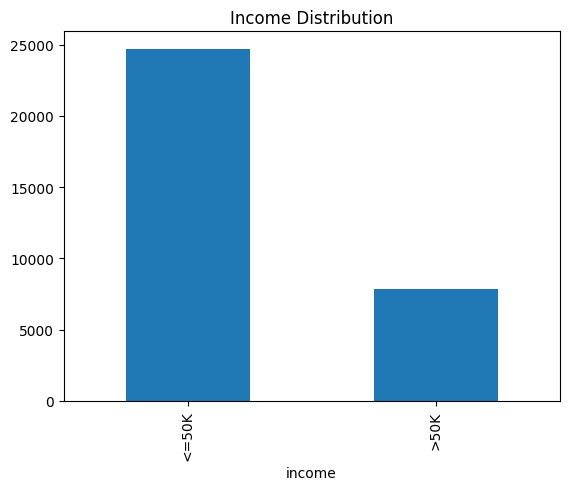

In [45]:
df["income"].value_counts().plot(kind="bar")

plt.title("Income Distribution")
plt.show()

## Step 5.2 - Numerical Feature Distributions

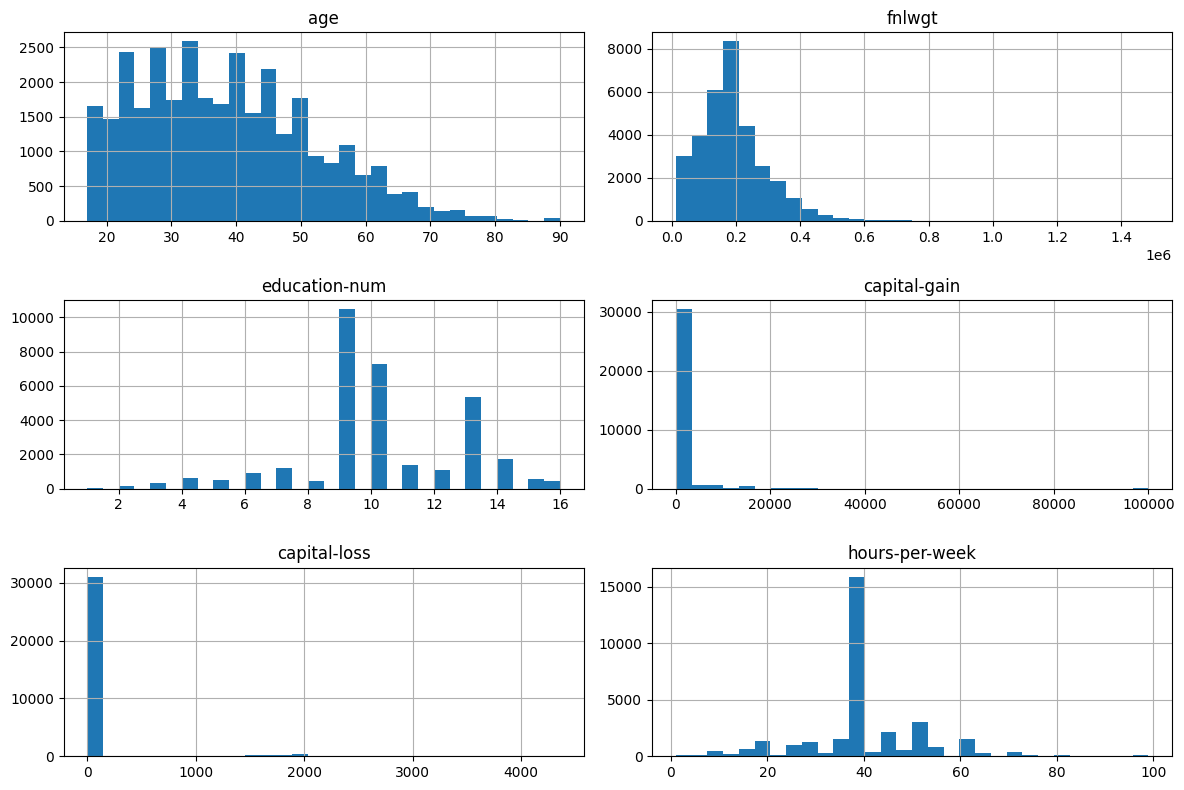

In [46]:
numerical_features = [
    "age",
    "fnlwgt",
    "education-num",
    "capital-gain",
    "capital-loss",
    "hours-per-week"
]
df[numerical_features].hist(
    figsize=(12, 8),
    bins=30
)

plt.tight_layout()
plt.show()

In [48]:
df.describe()

,age,fnlwgt,education-num,capital-gain,capital-loss,hours-per-week
count,32537.000000,3.253700e+04,32537.000000,32537.000000,32537.000000,32537.000000
mean,38.585549,1.897808e+05,10.081815,1078.443741,87.368227,40.440329
std,13.637984,1.055565e+05,2.571633,7387.957424,403.101833,12.346889
min,17.000000,1.228500e+04,1.000000,0.000000,0.000000,1.000000
25%,28.000000,1.178270e+05,9.000000,0.000000,0.000000,40.000000
50%,37.000000,1.783560e+05,10.000000,0.000000,0.000000,40.000000
75%,48.000000,2.369930e+05,12.000000,0.000000,0.000000,45.000000
max,90.000000,1.484705e+06,16.000000,99999.000000,4356.000000,99.000000


In [49]:
df.groupby("income")[[
    "age",
    "education-num",
    "capital-gain",
    "capital-loss",
    "hours-per-week"
]].mean()

,age,education-num,capital-gain,capital-loss,hours-per-week
income,,,,,
<=50K,36.787392,9.596081,148.884970,53.190258,38.842862
>50K,44.250925,11.612195,4007.164562,195.051282,45.473402


Comparing the average values of numerical features across income classes reveals several important patterns. Individuals earning more than $50K tend to be older, have higher education levels, work more hours per week, and report significantly larger capital gains and capital losses. Among the numerical features, education level, capital gain, and hours worked appear to have strong relationships with income and are likely to be important predictors in the classification model.

## 6. Preprocessing Pipeline
Create a preprocessing pipeline for classification.

Suggested approach:
- Impute or handle missing categorical values
- One-hot encode categorical variables
- Standardize numerical variables for models such as Logistic Regression
- Keep preprocessing fitted only on the training data

In [58]:
# copy before transfomations
df_model = df.copy()

# remove fnlwgt
# # Remove fnlwgt because it is a census sampling weight rather than a personal characteristic useful for income prediction.
df_model = df_model.drop("fnlwgt", axis=1)

# Capital gain and capital loss are highly right-skewed with many zeros and a few extreme values.
# Apply log(1 + x) transformation to reduce skewness and compress large values.
df_model["capital-gain"] = np.log1p(df_model["capital-gain"])
df_model["capital-loss"] = np.log1p(df_model["capital-loss"])

# Encode target
df_model["income"] = df_model["income"].map({
    "<=50K": 0,
    ">50K": 1
})

print(df_model.columns.tolist())

['age', 'workclass', 'education', 'education-num', 'marital-status', 'occupation', 'relationship', 'race', 'sex', 'capital-gain', 'capital-loss', 'hours-per-week', 'native-country', 'income']


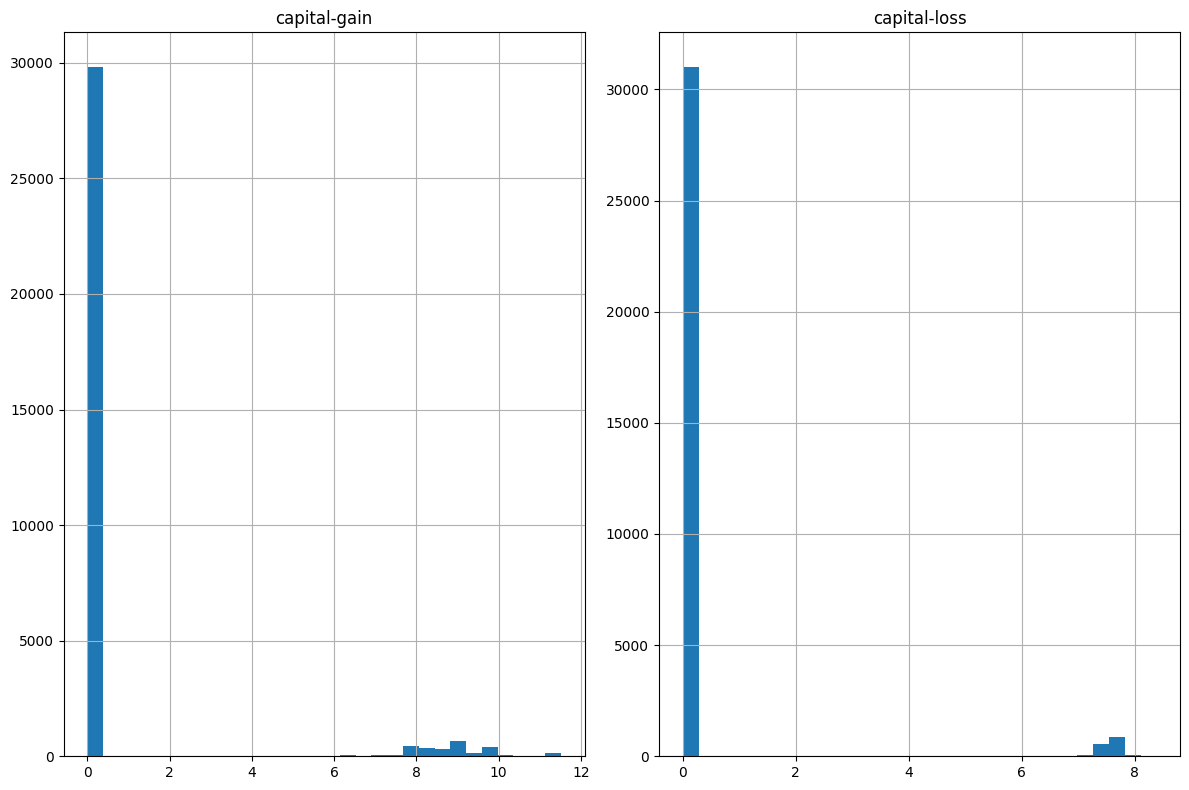

In [57]:
df_model[["capital-gain", "capital-loss"]].hist(
    figsize=(12, 8),
    bins=30
)

plt.tight_layout()
plt.show()

In [59]:
df_model[["capital-gain", "capital-loss"]].describe()

,capital-gain,capital-loss
count,32537.000000,32537.000000
mean,0.735163,0.350563
std,2.455562,1.585137
min,0.000000,0.000000
25%,0.000000,0.000000
50%,0.000000,0.000000
75%,0.000000,0.000000
max,11.512925,8.379539


## 7. Prepare Train/Test Data Splits


In [67]:
# split to feature and target
X = df_model.drop("income", axis=1)
y = df_model["income"]

# split to train and test
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

## define create_model function

In [60]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression


def create_model(
    numerical_features,
    categorical_features,
    max_iter=1000
):
    preprocessor = ColumnTransformer(
        transformers=[
            ("num", StandardScaler(), numerical_features),
            ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
        ]
    )

    model = Pipeline([
        ("preprocessor", preprocessor),
        ("classifier", LogisticRegression(max_iter=max_iter))
    ])

    return model

## define evaluate_model function

In [61]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)


def evaluate_model(model, X_test, y_test):
    y_pred = model.predict(X_test)

    print(f"Accuracy : {accuracy_score(y_test, y_pred):.4f}")
    print(f"Precision: {precision_score(y_test, y_pred):.4f}")
    print(f"Recall   : {recall_score(y_test, y_pred):.4f}")
    print(f"F1 Score : {f1_score(y_test, y_pred):.4f}")

    return y_pred

## Predict

In [68]:
categorical_features = [
    "workclass",
    "education",
    "marital-status",
    "occupation",
    "relationship",
    "race",
    "sex",
    "native-country"
]

numerical_features = [
    "age",
    "education-num",
    "capital-gain",
    "capital-loss",
    "hours-per-week"
]

# predict
model = create_model(
    numerical_features,
    categorical_features
)

model.fit(X_train, y_train)

y_pred = evaluate_model(
    model,
    X_test,
    y_test
)

Accuracy : 0.8508
Precision: 0.7239
Recall   : 0.6154
F1 Score : 0.6653


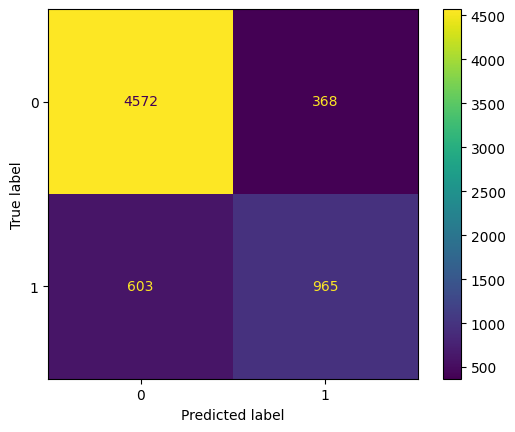

In [69]:
# confusion matrix
cm = confusion_matrix(y_test, y_pred)

ConfusionMatrixDisplay(cm).plot()

plt.show()

The confusion matrix shows that the model correctly classified 4,572 individuals earning $50K or less and 965 individuals earning more than $50K. However, the model produced 603 false negatives compared to 368 false positives, indicating that it is more likely to miss higher-income individuals than incorrectly classify lower-income individuals as high-income. This behavior is reflected in the lower recall score (61.5%) compared to precision (72.4%).

## 8. Optional: Class Imbalance Discussion
Adult Income is often imbalanced.

Questions to answer:
- Which class is the majority class?
- Why may accuracy be misleading?
- Which metric is more useful: precision, recall, or F1?
- Should class weights or resampling be considered?

In [70]:
df["income"].value_counts(normalize=True)

income
<=50K    0.759074
>50K     0.240926
Name: proportion, dtype: float64

### Which class is the majority class?  
<=50K ~ 76%  
>50K  ~ 24%  
  
Therefore:  
  
Majority class: <=50K  
Minority class: >50K

### Why may accuracy be misleading?  

Because the dataset is imbalanced.

A naive classifier that always predicts:

<=50K

would achieve approximately:

76% accuracy

without identifying any high-income individuals.

Therefore, accuracy alone does not adequately measure model performance.

### Which metric is more useful?  

more usefull is F1 Score

Accuracy : 0.8508
Precision: 0.7239
Recall   : 0.6154
F1 Score : 0.6653

Reason:

Precision measures how many predicted high-income individuals are actually high-income.
Recall measures how many actual high-income individuals are detected.
F1 balances both.

Since neither false positives nor false negatives are obviously more important in this homework, F1 is the most balanced metric.

### Should class weights or resampling be considered?  
Yes.

Because:

Minority class (>50K) = only 24%

and your confusion matrix shows:

False Negatives = 603
False Positives = 368

The model misses many high-income individuals.

### Test with a balanced model

In [72]:
# balanced model function

def create_balanced_model(
    numerical_features,
    categorical_features,
    max_iter=1000
):
    preprocessor = ColumnTransformer(
        transformers=[
            ("num", StandardScaler(), numerical_features),
            ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
        ]
    )

    model = Pipeline([
        ("preprocessor", preprocessor),
        (
            "classifier",
            LogisticRegression(
                max_iter=max_iter,
                class_weight="balanced"
            )
        )
    ])

    return model

In [73]:
balanced_model = create_balanced_model(
    numerical_features,
    categorical_features
)

balanced_model.fit(X_train, y_train)

evaluate_model(
    balanced_model,
    X_test,
    y_test
)

Accuracy : 0.8059
Precision: 0.5642
Recall   : 0.8552
F1 Score : 0.6798


array([0, 1, 0, ..., 1, 0, 0], shape=(6508,))

compare:

baseline:
Accuracy : 0.8508
Precision: 0.7239
Recall   : 0.6154
F1 Score : 0.6653

balanced:
Accuracy : 0.8059
Precision: 0.5642
Recall   : 0.8552
F1 Score : 0.6798

Which model is better?
If the main is overall correctness

Choose:

Baseline

because:

Accuracy = 85.1%

is higher.

If the main is finding high-income individuals

Choose:

Balanced

because:

Recall = 85.5%

is better.


## 9. Bonus: Compare Before vs After Preprocessing

Goal: show why preprocessing matters.

Suggested comparison:
1. Try to train a classifier on the raw dataset.
2. Observe what fails or performs poorly.
3. Train the same classifier after preprocessing.
4. Compare metrics and explain the difference.

Questions to answer:
- Can the model train on raw categorical columns?
- What preprocessing steps were required?
- Did performance improve after preprocessing?
- Which metric changed the most?

### 1. Try to train a classifier on the raw dataset. 

In [79]:
df_raw = df = pd.read_excel("adult.xlsx")

In [80]:
# no Data Cleaning & Feature Engineering preprocessing:
# empty values, duplication, log transformation, remove not relvant feature

# Encode target
df_raw["income"] = df_raw["income"].str.strip()

df_raw["income"] = df_raw["income"].map({
    "<=50K": 0,
    ">50K": 1
})

# Split X and y
X_raw = df_raw.drop("income", axis=1)
y_raw = df_raw["income"]

In [81]:
# Train/Test split
X_train_raw, X_test_raw, y_train_raw, y_test_raw = train_test_split(
    X_raw,
    y_raw,
    test_size=0.2,
    stratify=y_raw,
    random_state=42
)

In [82]:
# Define feature groups
numerical_features_raw = [
    "age",
    "fnlwgt",
    "education-num",
    "capital-gain",
    "capital-loss",
    "hours-per-week"
]

categorical_features_raw = [
    "workclass",
    "education",
    "marital-status",
    "occupation",
    "relationship",
    "race",
    "sex",
    "native-country"
]

raw_model = create_model(
    numerical_features_raw,
    categorical_features_raw
)

raw_model.fit(X_train_raw, y_train_raw)

evaluate_model(raw_model, X_test_raw, y_test_raw)

Accuracy : 0.8560
Precision: 0.7397
Recall   : 0.6199
F1 Score : 0.6745


array([0, 0, 1, ..., 1, 0, 0], shape=(6513,))

no big difference 
preprocessing
Accuracy : 0.8508
Precision: 0.7239
Recall   : 0.6154
F1 Score : 0.6653 

without preprocessing - Data Cleaning & Feature Engineering. But still scaling
Accuracy : 0.8560
Precision: 0.7397
Recall   : 0.6199
F1 Score : 0.6745


#### minimize preprocessing at all

In [84]:
# no Data Cleaning & Feature Engineering

df_raw2 = df = pd.read_excel("adult.xlsx")

In [85]:
# Encode target
df_raw2["income"] = df_raw2["income"].str.strip()

df_raw2["income"] = df_raw2["income"].map({
    "<=50K": 0,
    ">50K": 1
})

# Split X and y
X_raw2 = df_raw2.drop("income", axis=1)
y_raw2 = df_raw2["income"]

In [86]:
# Train/Test split
X_train_raw2, X_test_raw2, y_train_raw2, y_test_raw2 = train_test_split(
    X_raw2,
    y_raw2,
    test_size=0.2,
    stratify=y_raw2,
    random_state=42
)

In [87]:
numerical_features_raw2 = [
    "age",
    "fnlwgt",
    "education-num",
    "capital-gain",
    "capital-loss",
    "hours-per-week"
]

categorical_features_raw2 = [
    "workclass",
    "education",
    "marital-status",
    "occupation",
    "relationship",
    "race",
    "sex",
    "native-country"
]

In [88]:
def create_model_without_scaling(
    numerical_features,
    categorical_features,
    max_iter=1000
):
    preprocessor = ColumnTransformer(
        transformers=[
            ("num", "passthrough", numerical_features),
            ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
        ]
    )

    model = Pipeline([
        ("preprocessor", preprocessor),
        ("classifier", LogisticRegression(max_iter=max_iter))
    ])

    return model

In [89]:
model_no_scaling = create_model_without_scaling(
    numerical_features_raw2,
    categorical_features_raw2
)

model_no_scaling.fit(
    X_train_raw2,
    y_train_raw2
)

evaluate_model(
    model_no_scaling,
    X_test_raw2,
    y_test_raw2
)

Accuracy : 0.8474
Precision: 0.7396
Recall   : 0.5651
F1 Score : 0.6406


c:\Valentina\projects\data-camp\db-analyse\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


array([0, 0, 1, ..., 1, 0, 0], shape=(6513,))

The model without numerical scaling produced a convergence warning, meaning Logistic Regression could not fully optimize within the iteration limit. This is expected because the numerical features have very different scales. After applying StandardScaler in the preprocessing pipeline, the model trained more reliably and achieved a better F1 score and recall.

preprocessing ans scaling  
Accuracy : 0.8508  
Precision: 0.7239  
Recall   : 0.6154  
F1 Score : 0.6653   
  
without preprocessing and scaling   
Accuracy : 0.8474  
Precision: 0.7396  
Recall   : 0.5651  
F1 Score : 0.6406

looks like standart scaling and removing of not relevant feature are the most usefull preprocessing here

What preprocessing steps were required?  
one hot encoding  
encode target values  
because LogisticRegression can not work with categorical values